Challenge A: Linear Least Squares vs Polynomial Fit (cubic polynomial)
Least Squares:
Slope: 0.7647333434215868, Intercept: -0.2561381757308562
Mean Squared Error: 0.5138764491938411, R-Squared: 0.08661453112737139

Polynomial Fit (degree 3):
Coefficients: [ 0.5347704   4.76739586 -4.42828175  0.61799775]
Mean Squared Error: 0.3420236192756962, R-Squared: 0.39207293047242975

Better MSE:  Polynomial Fit
Better R-Squared:  Polynomial Fit
The Polynomial Fit method is the better fit.


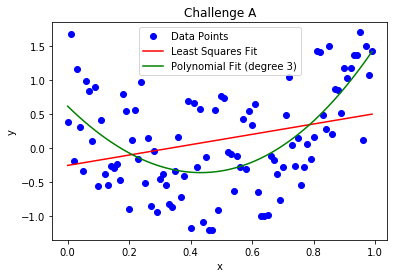

Challenge B: Linear Least Squares vs Polynomial Fit (varying-degree polynomial)
Polynomial Fit (degree 1, underfit):
Coefficients: [ 0.76473334 -0.25613818]
Mean Squared Error: 0.513876449193841, R-Squared: 0.0866145311273715

Polynomial Fit (degree 2, underfit):
Coefficients: [ 5.5615299  -4.74118125  0.64316121]
Mean Squared Error: 0.34212561182850143, R-Squared: 0.39189164464815873

Polynomial Fit (degree 4, overfit):
Coefficients: [  9.48904468 -18.25353808  16.6852293   -7.01972629   0.74046746]
Mean Squared Error: 0.33998797100262834, R-Squared: 0.3956911767557002

Polynomial Fit (degree 5, overfit):
Coefficients: [ -51.52160833  137.00502529 -130.1928191    57.93664903  -12.73861572
    0.91594305]
Mean Squared Error: 0.33620881945188047, R-Squared: 0.4024083986025774

Polynomial Fit (degree 6, overfit):
Coefficients: [-236.14129197  649.81802881 -650.48324863  283.39566601  -43.18749724
   -3.02073851    0.70975872]
Mean Squared Error: 0.33123030759684524, R-Squared: 0.41125741

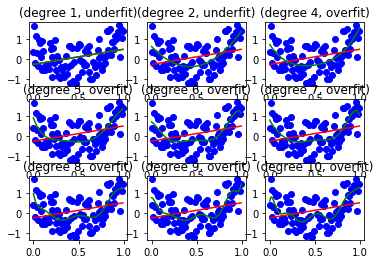

Challenge C: The Vandermonde
Polynomial Fit (degree 2):
Coefficients: [ 0.64316121 -4.74118125  5.5615299 ]
Mean Squared Error: 0.34212561182850143, R-Squared: 0.39189164464815873



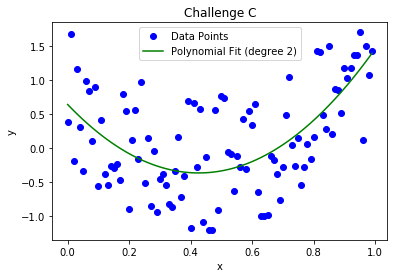

In [74]:
import numpy as np
import matplotlib.pyplot as plt


def compute_mse(Y, Y_fit):
    return np.mean((Y - Y_fit)**2)


def compute_rsq(Y, Y_fit):
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - Y_fit)**2)
    return 1.0 - (ss_res / ss_total)


def plot_lstsq(X, Y_fit):
    plt.plot(X, Y_fit, 'r-', label="Least Squares Fit")


def plot_polyfit(X, Y_fit, comment=""):
    plt.plot(X, Y_fit, 'g-', label=f"Polynomial Fit {comment}")


def solve_and_plot_lstsq(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
    Y_fit = m*X+c
    mse = compute_mse(Y, Y_fit)
    rsq = compute_rsq(Y, Y_fit)
    plot_lstsq(X, Y_fit)
    print("Least Squares:")
    print(f"Slope: {m}, Intercept: {c}")
    print(f"Mean Squared Error: {mse}, R-Squared: {rsq}\n")
    return mse, rsq, Y_fit


def solve_and_plot_polyfit(X, Y, degree=3, comment=""):
    if not comment:
        comment = f"(degree {degree})"
    c = np.polyfit(X, Y, degree)
    p = np.poly1d(c)
    Y_fit = p(X)
    mse = compute_mse(Y, Y_fit)
    rsq = compute_rsq(Y, Y_fit)
    plot_polyfit(X, Y_fit, comment)
    print(f"Polynomial Fit {comment}:")
    print(f"Coefficients: {c}")
    print(f"Mean Squared Error: {mse}, R-Squared: {rsq}\n")
    return mse, rsq, Y_fit


def evaluate_fits(lstsq_stats, polyfit_stats):
    lstsq_mse = lstsq_stats[0] < polyfit_stats[0]
    lstsq_rsq = lstsq_stats[1] > polyfit_stats[1]
    print("Better MSE: ", "Least Squares" if lstsq_mse else "Polynomial Fit")
    print("Better R-Squared: ", "Least Squares" if lstsq_rsq else "Polynomial Fit")
    if lstsq_mse and lstsq_rsq:
        print("The Least Squares method is the better fit.")
    elif not (lstsq_mse or lstsq_rsq):
        print("The Polynomial Fit method is the better fit.")
    else:
        print("The best fit is unclear.")


# X = np.sort(np.random.rand(100))
# Y = np.random.rand(100)
X = np.arange(0.0, 1.0, 0.01)
Y = 5.0*(X**2) - 4.5*X + 0.8 + (2.0*np.random.rand(len(X))-1.0)

# Challenge A: Linear Least Squares vs Polynomial Fit (cubic polynomial)
print(f"Challenge A: Linear Least Squares vs Polynomial Fit (cubic polynomial)")
plt.plot(X, Y, 'bo', label="Data Points")
lstsq_stats = solve_and_plot_lstsq(X, Y)
polyfit_stats = solve_and_plot_polyfit(X, Y)
plt.title("Challenge A")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
evaluate_fits(lstsq_stats, polyfit_stats)
plt.show()

# Challenge B: Linear Least Squares vs Polynomial Fit (varying-degree polynomial)
print(f"Challenge B: Linear Least Squares vs Polynomial Fit (varying-degree polynomial)")
for i in range(1, 10):
    # plt.figure(figsize=(1,1))
    plt.subplot(3, 3, i)
    if i > 2:
        i += 1
    comment = f"(degree {i}, " + ("underfit)" if i < 3 else "overfit)")
    plt.plot(X, Y, 'bo', label="Data Points")
    plot_lstsq(X, lstsq_stats[2])
    solve_and_plot_polyfit(X, Y, i, comment)
    plt.title(comment)
    # plt.legend()
plt.show()

# Challenge C: The Vandermonde
def create_vandermonde_matrix(X, degree):
    return np.column_stack([X**d for d in range(degree+1)])

print(f"Challenge C: The Vandermonde")
plt.plot(X, Y, 'bo', label="Data Points")

V = create_vandermonde_matrix(X, 2)
VT_V = np.dot(V.T, V)
VT_Y = np.dot(V.T, Y)
a = np.linalg.solve(VT_V, VT_Y)
Y_fit = a[0] + a[1]*X + a[2]*(X**2)
mse = compute_mse(Y, Y_fit)
rsq = compute_rsq(Y, Y_fit)
plot_polyfit(X, Y_fit, "(degree 2)")
print(f"Polynomial Fit (degree 2):")
print(f"Coefficients: {a}")
print(f"Mean Squared Error: {mse}, R-Squared: {rsq}\n")

plt.title("Challenge C")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
